В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням алгоритмів бустингу: XGBoost та LightGBM, а також використаємо бібліотеку HyperOpt для оптимізації гіперпараметрів.

0. Зчитайте дані `train.csv` в змінну `raw_df` та скористайтесь наведеним кодом нижче аби розділити дані на трнувальні та валідаційні і розділити дані на ознаки з матириці Х та цільову змінну. Назви змінних `train_inputs, train_targets, train_inputs, train_targets` можна змінити на ті, які Вам зручно.

  Наведений скрипт - частина отриманого мною скрипта для обробки даних. Ми тут не викнуємо масштабування та обробку категоріальних змінних, бо хочемо це делегувати алгоритмам, які будемо використовувати. Якщо щось не розумієте в наведених скриптах, рекомендую розібратись: навичка читати код - важлива складова роботи в машинному навчанні.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from typing import Tuple, Dict, Any


def split_train_val(df: pd.DataFrame, target_col: str, test_size: float = 0.2, random_state: int = 42) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Split the dataframe into training and validation sets.

    Args:
        df (pd.DataFrame): The raw dataframe.
        target_col (str): The target column for stratification.
        test_size (float): The proportion of the dataset to include in the validation split.
        random_state (int): Random state for reproducibility.

    Returns:
        Tuple[pd.DataFrame, pd.DataFrame]: Training and validation dataframes.
    """
    train_df, val_df = train_test_split(df, test_size=test_size, random_state=random_state, stratify=df[target_col])
    return train_df, val_df


def separate_inputs_targets(df: pd.DataFrame, input_cols: list, target_col: str) -> Tuple[pd.DataFrame, pd.Series]:
    """
    Separate inputs and targets from the dataframe.

    Args:
        df (pd.DataFrame): The dataframe.
        input_cols (list): List of input columns.
        target_col (str): Target column.

    Returns:
        Tuple[pd.DataFrame, pd.Series]: DataFrame of inputs and Series of targets.
    """
    inputs = df[input_cols].copy()
    targets = df[target_col].copy()
    return inputs, targets

In [ ]:
raw_df = pd.read_csv('drive/MyDrive/Colab Notebooks/train.csv')

In [ ]:
raw_df[:5]

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15779985.0,Nwankwo,678.0,France,Male,29.0,4.0,0.00,3.0,1.0,0.0,180626.36,0.0
1,1,15650086.0,Ch'in,687.0,France,Female,34.0,1.0,0.00,2.0,0.0,1.0,63736.17,0.0
2,2,15733602.0,Thompson,682.0,France,Female,52.0,6.0,0.00,3.0,0.0,0.0,179655.87,1.0
3,3,15645794.0,Macleod,753.0,Germany,Male,44.0,6.0,83347.25,2.0,1.0,0.0,161407.48,0.0
4,4,15633840.0,Hsia,544.0,Germany,Female,55.0,0.0,107747.57,1.0,1.0,0.0,176580.86,1.0


In [ ]:
raw_df.dtypes

,0
id,int64
CustomerId,float64
Surname,object
CreditScore,float64
Geography,object
Gender,object
Age,float64
Tenure,float64
Balance,float64
NumOfProducts,float64


In [ ]:
target_column = "Exited" #цільова змінна

In [ ]:
train_df, val_df = train_test_split(raw_df, test_size=0.2, random_state=42, stratify=raw_df[target_column]) #розділення на трейн та валідейшен


In [ ]:
train_df.shape, val_df.shape

((12000, 14), (3000, 14))

In [ ]:
input_cols = [col for col in raw_df.columns if col not in ['id', 'CustomerId', 'Surname', target_column]] #визначення вхідних даних

In [ ]:
input_cols

['CreditScore',
 'Geography',
 'Gender',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary']

In [ ]:
train_inputs = train_df[input_cols].copy()
train_targets = train_df[target_column].copy()

val_inputs = val_df[input_cols].copy()
val_targets = val_df[target_column].copy()

In [ ]:
train_inputs

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
7180,682.0,France,Male,30.0,1.0,131394.56,1.0,1.0,1.0,143952.24
10393,684.0,France,Female,39.0,2.0,178058.06,1.0,1.0,0.0,145518.31
80,705.0,Germany,Male,35.0,6.0,116320.68,2.0,1.0,0.0,174431.01
3365,669.0,Spain,Male,58.0,0.0,0.00,2.0,0.0,1.0,51565.98
12236,707.0,France,Male,21.0,3.0,0.00,2.0,1.0,1.0,148564.76
...,...,...,...,...,...,...,...,...,...,...
9493,633.0,France,Female,33.0,4.0,0.00,2.0,0.0,0.0,123537.05
8463,673.0,France,Female,40.0,1.0,0.00,1.0,1.0,1.0,47832.82
8143,621.0,France,Male,29.0,8.0,0.00,2.0,1.0,1.0,133535.29
11512,590.0,Spain,Male,42.0,7.0,0.00,2.0,0.0,0.0,72643.95


In [ ]:
train_inputs.shape, val_inputs.shape

((12000, 10), (3000, 10))

In [ ]:
train_targets.shape, val_targets.shape

((12000,), (3000,))

1. В тренувальному та валідаційному наборі перетворіть категоріальні ознаки на тип `category`. Можна це зробити двома способами:
 1. `df[col_name].astype('category')`, як було продемонстровано в лекції
 2. використовуючи метод `pd.Categorical(df[col_name])`

In [ ]:
train_inputs[['Geography', 'Gender']] = train_inputs[['Geography', 'Gender']].apply(lambda col: col.astype('category'))
val_inputs[['Geography', 'Gender']] = val_inputs[['Geography', 'Gender']].apply(lambda col: col.astype('category'))


In [ ]:
print(train_inputs.dtypes)


CreditScore         float64
Geography          category
Gender             category
Age                 float64
Tenure              float64
Balance             float64
NumOfProducts       float64
HasCrCard           float64
IsActiveMember      float64
EstimatedSalary     float64
dtype: object


2. Навчіть на отриманих даних модель `XGBoostClassifier`. Параметри алгоритму встановіть на свій розсуд, ми далі будемо їх тюнити. Рекомендую тренувати не дуже складну модель.

  Опис всіх конфігураційних параметрів XGBoostClassifier - тут https://xgboost.readthedocs.io/en/stable/parameter.html#global-config

  **Важливо:** зробіть такі налаштування `XGBoostClassifier` аби він самостійно обробляв незаповнені значення в даних і обробляв категоріальні колонки.

  Можна також, якщо працюєте в Google Colab, увімкнути можливість використання GPU (`Runtime -> Change runtime type -> T4 GPU`) і встановити параметр `device='cuda'` в `XGBoostClassifier` для пришвидшення тренування бустинг моделі.
  
  Після тренування моделі
  1. Виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах.
  2. Зробіть висновок про отриману модель: вона хороша/погана, чи є high bias/high variance?
  3. Порівняйте якість цієї моделі з тою, що ви отрмали з використанням DecisionTrees раніше. Чи вийшло покращити якість?

In [ ]:
!pip3 install xgboost

In [ ]:
from xgboost import XGBClassifier

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
xgb_clf = XGBClassifier(
    max_depth=3,
    n_estimators=10,
    enable_categorical=True,  # для категорійних ознак
    missing=np.nan,  # явне вказування пропущених значень
)

xgb_clf.fit(train_inputs, train_targets)

train_pred = xgb_clf.predict(train_inputs)
val_pred = xgb_clf.predict(val_inputs)

train_probs = xgb_clf.predict_proba(train_inputs)[:, 1]
val_probs = xgb_clf.predict_proba(val_inputs)[:, 1]

# Обчислення AUROC
train_auc = roc_auc_score(train_targets, train_probs)
val_auc = roc_auc_score(val_targets, val_probs)

# Вивід метрик
print(classification_report(train_targets, train_pred, digits=4))
print(classification_report(val_targets, val_pred, digits=4))
print(f"Train AUROC: {train_auc:.4f}")
print(f"Validation AUROC: {val_auc:.4f}")

              precision    recall  f1-score   support

         0.0     0.9146    0.9639    0.9386      9558
         1.0     0.8210    0.6478    0.7242      2442

    accuracy                         0.8996     12000
   macro avg     0.8678    0.8059    0.8314     12000
weighted avg     0.8956    0.8996    0.8950     12000

              precision    recall  f1-score   support

         0.0     0.9137    0.9569    0.9348      2390
         1.0     0.7928    0.6459    0.7118       610

    accuracy                         0.8937      3000
   macro avg     0.8532    0.8014    0.8233      3000
weighted avg     0.8891    0.8937    0.8895      3000

Train AUROC: 0.9330
Validation AUROC: 0.9326


**Висновок**

**train accuracy 0.8996\
validation accuracy 0.8937**\
Немає великого розриву між тренувальним і валідаційним набором, що свідчить про стабільність моделі.

**precision train 0.8210\
validation   0.7928** \
Модель досить добре передбачає позитивний клас

**recall train 0.6478\
validation   0.6459** \
Можна покращити — модель пропускає частину позитивних прикладів

**F1 train 0.7242	\
validation 0.7118**\
Баланс precision/recall непоганий

Немає high bias — точність на тренуванні висока
Немає high variance — точність на валідації майже така сама
Модель узагальнює добре, не має оверфіту

ця модель краще узагальнює, і має менший ризик переобучення ніж моя модель з десіжен трі, яка мала ризик оверфіту

3. Використовуючи бібліотеку `Hyperopt` і приклад пошуку гіперпараметрів для `XGBoostClassifier` з лекції знайдіть оптимальні значення гіперпараметрів `XGBoostClassifier` для нашої задачі. Задайте свою сітку гіперпараметрів виходячи з тих параметрів, які ви б хотіли перебрати. Поставте кількість раундів в підборі гіперпараметрів рівну **20**.

  **Увага!** Для того, аби скористатись hyperopt, нам треба задати функцію `objective`. В ній ми маємо задати loss - це може будь-яка метрика, але бажано використовувтаи ту, яка цільова в вашій задачі. Чим менший лосс - тим ліпша модель на думку hyperopt. Тож, тут нам треба задати loss - негативне значення AUROC. В лекції ми натомість використовували Accuracy.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення гіперпараметрів
    - створіть в окремій зміній `final_clf` модель `XGBoostClassifier` з найкращими гіперпараметрами
    - навчіть модель `final_clf`
    - оцініть якість моделі `final_clf` на тренувальній і валідаційній вибірках з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пунктом (2) цього завдання?

In [ ]:
!pip install hyperopt

In [ ]:
import xgboost as xgb
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score

In [ ]:
def objective(params):
    clf = xgb.XGBClassifier(
    n_estimators=int(params['n_estimators']),
        learning_rate=params['learning_rate'],
        max_depth=int(params['max_depth']),
        min_child_weight=params['min_child_weight'],  # Мінімальна сума ваг всіх вибірок, необхідна в кінцевому вузлі
        subsample=params['subsample'],  # Частка вибірок, що використовуються для побудови кожного дерева
        colsample_bytree=params['colsample_bytree'],  # Частка ознак, що використовуються при побудові кожного дерева
        gamma=params['gamma'],  # Мінімальне зменшення втрат, необхідне для виконання поділу
        reg_alpha=params['reg_alpha'],  # Параметр регуляризації L1 (Lasso)
        reg_lambda=params['reg_lambda'],  # Параметр регуляризації L2 (Ridge)
        enable_categorical=True,
        use_label_encoder=False,
        missing=np.nan,
        early_stopping_rounds=20
    )

    clf.fit(
        train_inputs,
        train_targets,
        eval_set=[(val_inputs, val_targets)],
        verbose=False)
    val_probs = clf.predict_proba(val_inputs)[:, 1]
    auc = roc_auc_score(val_targets, val_probs)

    return {'loss': -auc, 'status': STATUS_OK}

# Простір гіперпараметрів
space = {
    'n_estimators': hp.quniform('n_estimators', 50, 500, 25),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.3),
    'max_depth': hp.quniform('max_depth', 3, 15, 1),
    'min_child_weight': hp.quniform('min_child_weight', 1, 10, 1),
    'subsample': hp.uniform('subsample', 0.5, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1.0),
    'gamma': hp.uniform('gamma', 0, 0.5),
    'reg_alpha': hp.uniform('reg_alpha', 0, 1),
    'reg_lambda': hp.uniform('reg_lambda', 0, 1)
}

# Оптимізація
trials = Trials()
best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=20, trials=trials)

# Перетворення значень гіперпараметрів у кінцеві типи
best['n_estimators'] = int(best['n_estimators'])
best['max_depth'] = int(best['max_depth'])
best['min_child_weight'] = int(best['min_child_weight'])

print("Найкращі гіперпараметри: ", best)

# Навчання фінальної моделі з найкращими гіперпараметрами
final_clf = xgb.XGBClassifier(
    n_estimators=best['n_estimators'],
    learning_rate=best['learning_rate'],
    max_depth=best['max_depth'],
    min_child_weight=best['min_child_weight'],
    subsample=best['subsample'],
    colsample_bytree=best['colsample_bytree'],
    gamma=best['gamma'],
    reg_alpha=best['reg_alpha'],
    reg_lambda=best['reg_lambda'],
    enable_categorical=True,
    use_label_encoder=False,
    missing=np.nan,
)

final_clf.fit(train_inputs, train_targets)
final_probs = final_clf.predict_proba(val_inputs)[:, 1]
final_auc = roc_auc_score(val_targets, final_probs)
print("AUROC на валідаційній вибірці: {:.4f}".format(final_auc))

  5%|▌         | 1/20 [00:00<00:03,  5.05trial/s, best loss: -0.937676109472529]

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:386: UserWarning: [11:44:59] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:386: UserWarning: [11:45:00] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()



 10%|█         | 2/20 [00:00<00:07,  2.46trial/s, best loss: -0.937676109472529]

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:386: UserWarning: [11:45:00] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()



 15%|█▌        | 3/20 [00:01<00:06,  2.57trial/s, best loss: -0.937676109472529]

...

 95%|█████████▌| 19/20 [00:16<00:00,  1.52trial/s, best loss: -0.937676109472529]

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:386: UserWarning: [11:45:16] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()



100%|██████████| 20/20 [00:17<00:00,  1.12trial/s, best loss: -0.937676109472529]
Найкращі гіперпараметри:  {'colsample_bytree': np.float64(0.9166418154415732), 'gamma': np.float64(0.4884041028129414), 'learning_rate': np.float64(0.081770378700158), 'max_depth': 3, 'min_child_weight': 6, 'n_estimators': 225, 'reg_alpha': np.float64(0.48153421407921193), 'reg_lambda': np.float64(0.05137573056344269), 'subsample': np.float64(0.8675276748521761)}


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [11:45:17] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


AUROC на валідаційній вибірці: 0.9365


In [ ]:
final_pred = final_clf.predict(val_inputs)
final_probs = final_clf.predict_proba(val_inputs)[:, 1]

print(classification_report(val_targets, final_pred, digits=4))
print("AUROC на валідаційній вибірці: {:.4f}".format(roc_auc_score(val_targets, final_probs)))


              precision    recall  f1-score   support

         0.0     0.9221    0.9561    0.9388      2390
         1.0     0.7989    0.6836    0.7367       610

    accuracy                         0.9007      3000
   macro avg     0.8605    0.8198    0.8378      3000
weighted avg     0.8971    0.9007    0.8977      3000

AUROC на валідаційній вибірці: 0.9365


**Тюнінг гіперпараметрів дав легке покращення recall без суттєвого падіння інших метрик.**

In [ ]:
from pprint import pprint
pprint(best)

{'colsample_bytree': np.float64(0.9166418154415732),
 'gamma': np.float64(0.4884041028129414),
 'learning_rate': np.float64(0.081770378700158),
 'max_depth': 3,
 'min_child_weight': 6,
 'n_estimators': 225,
 'reg_alpha': np.float64(0.48153421407921193),
 'reg_lambda': np.float64(0.05137573056344269),
 'subsample': np.float64(0.8675276748521761)}


In [ ]:
# Якщо best містить np.float64, перетворимо на звичайні float
clean_best = {k: float(v) if hasattr(v, 'item') else v for k, v in best.items()}

# Створення моделі з найкращими гіперпараметрами
final_clf = XGBClassifier(
    **clean_best,
    enable_categorical=True,
    use_label_encoder=False,
    random_state=42
)

# Навчання моделі
final_clf.fit(train_inputs, train_targets)

# Отримання ймовірностей позитивного класу
train_probs = final_clf.predict_proba(train_inputs)[:, 1]
val_probs = final_clf.predict_proba(val_inputs)[:, 1]

# Обчислення AUROC
train_auc = roc_auc_score(train_targets, train_probs)
val_auc = roc_auc_score(val_targets, val_probs)

# Вивід результатів
print(f"Train AUROC: {train_auc:.4f}")
print(f"Validation AUROC: {val_auc:.4f}")


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [11:47:21] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Train AUROC: 0.9480
Validation AUROC: 0.9364


**Висновок**\
Train AUROC зріс, що свідчить про кращу здатність моделі навчитися розрізняти класи.
Validation AUROC також покращився, хоч і незначно, але модель стала стабільнішою і краще узагальнює на нових даних.
Відсутність великого розриву між train і validation AUROC говорить про відсутність переобучення.

Ця модель дає кращі результати ніж попередня без тюнінгу гіперпараметрів

4. Навчіть на наших даних модель LightGBM. Параметри алгоритму встановіть на свій розсуд, ми далі будемо їх тюнити. Рекомендую тренувати не дуже складну модель.

  Опис всіх конфігураційних параметрів LightGBM - тут https://lightgbm.readthedocs.io/en/latest/Parameters.html

  **Важливо:** зробіть такі налаштування LightGBM аби він самостійно обробляв незаповнені значення в даних і обробляв категоріальні колонки.

  Аби передати категоріальні колонки в LightGBM - необхідно виявити їх індекси і передати в параметрі `cat_feature=cat_feature_indexes`

  Після тренування моделі
  1. Виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах.
  2. Зробіть висновок про отриману модель: вона хороша/погана, чи є high bias/high variance?
  3. Порівняйте якість цієї моделі з тою, що ви отрмали з використанням XGBoostClassifier раніше. Чи вийшло покращити якість?

In [ ]:
!pip install lightgbm


In [ ]:
import lightgbm as lgb
print(lgb.__version__)

4.6.0


In [ ]:
cat_feature_indexes = [
    train_inputs.columns.get_loc(col)
    for col in train_inputs.columns
    if train_inputs[col].dtype.name == 'category'
]

In [ ]:
cat_feature_indexes

[1, 2]

In [ ]:
lgb_clf = lgb.LGBMClassifier(
    max_depth=3,
    n_estimators=50,
    learning_rate=0.1,
    cat_feature=cat_feature_indexes,  # для автоматичного розпізнавання категорійних ознак
    missing=np.nan,  # явне вказування пропущених значень
)

lgb_clf.fit(train_inputs, train_targets, eval_set=[(val_inputs, val_targets)])

train_pred = lgb_clf.predict(train_inputs)
val_pred = lgb_clf.predict(val_inputs)

# Прогноз ймовірностей для AUROC
train_probs = lgb_clf.predict_proba(train_inputs)[:, 1]
val_probs = lgb_clf.predict_proba(val_inputs)[:, 1]

# Обчислення AUROC
train_auc = roc_auc_score(train_targets, train_probs)
val_auc = roc_auc_score(val_targets, val_probs)

print("Train AUROC: {:.4f}".format(train_auc))
print("Validation AUROC: {:.4f}".format(val_auc))

print("\nTrain Classification Report:")
print(classification_report(train_targets, train_pred, digits=4))

print("Validation Classification Report:")
print(classification_report(val_targets, val_pred, digits=4))

[LightGBM] [Warning] Unknown parameter: missing
[LightGBM] [Warning] categorical_feature is set with cat_feature=1,2, categorical_column=1,2 will be ignored. Current value: categorical_feature=1,2
[LightGBM] [Warning] Unknown parameter: missing
[LightGBM] [Info] Number of positive: 2442, number of negative: 9558
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001744 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 843
[LightGBM] [Info] Number of data points in the train set: 12000, number of used features: 10
[LightGBM] [Warning] Unknown parameter: missing
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203500 -> initscore=-1.364561
[LightGBM] [Info] Start training from score -1.364561
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[L

**Висновок**

**поточні**\
Train AUROC: 0.9388\
Validation AUROC: 0.9362

**попередні** \
Train AUROC: 0.9480\
Validation AUROC: 0.9364

Поточна модель LightGBM показала практично ідентичну якість на валідації, як і попередня XGBoost з тюнінгом.

Незважаючи на трохи нижчий Train AUROC, вона демонструє стабільну узагальнюючу здатність і може бути використана як ефективна альтернатива без складної оптимізації.


5. Використовуючи бібліотеку `Hyperopt` і приклад пошуку гіперпараметрів для `LightGBM` з лекції знайдіть оптимальні значення гіперпараметрів `LightGBM` для нашої задачі. Задайте свою сітку гіперпараметрів виходячи з тих параметрів, які ви б хотіли перебрати. Поставте кількість раундів в підборі гіперпараметрів рівну **10**.

  **Увага!** Для того, аби скористатись hyperopt, нам треба задати функцію `objective`. І тут ми також ставимо loss - негативне значення AUROC, як і при пошуці гіперпараметрів для XGBoost. До речі, можна спробувати написати код так, аби в objective передавати лише модель і не писати схожий код двічі :)

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення гіперпараметрів
    - створіть в окремій зміній `final_lgb_clf` модель `LightGBM` з найкращими гіперпараметрами
    - навчіть модель `final_lgb_clf`
    - оцініть якість моделі `final_lgb_clf` на тренувальній і валідаційній вибірках з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пунктом (4) цього завдання?

In [ ]:
def objective(params):
    clf = lgb.LGBMClassifier(
        n_estimators=10, # Кількість дерев у ансамблі (кількість ітерацій бустингу)
        learning_rate=params['learning_rate'],  # Коефіцієнт, на який зменшується внесок кожного доданого дерева
        max_depth=int(params['max_depth']),  # Максимальна глибина кожного дерева
        num_leaves=int(params['num_leaves']),  # Максимальна кількість листків, що дозволяємо кожному дереву мати.
        min_child_weight=params['min_child_weight'],  # Мінімальна сума ваг всіх вибірок, необхідна в кінцевому вузлі
        subsample=params['subsample'],  # Частка вибірок, що використовуються для побудови кожного дерева
        colsample_bytree=params['colsample_bytree'],  # Частка ознак, що використовуються при побудові кожного дерева
        reg_alpha=params['reg_alpha'],  # Параметр регуляризації L1 (Lasso)
        reg_lambda=params['reg_lambda'],  # Параметр регуляризації L2 (Ridge)
        min_split_gain=params['min_split_gain'],  # Мінімальне зменшення втрат, необхідне для виконання поділу
        cat_feature=cat_feature_indexes  # Індекси категорійних ознак
    )

    clf.fit(train_inputs, train_targets, eval_set=[(val_inputs, val_targets)])
    val_probs = clf.predict_proba(val_inputs)[:, 1]
    auc = roc_auc_score(val_targets, val_probs)

    return {'loss': -auc, 'status': STATUS_OK}

# Простір гіперпараметрів
space = {
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.3),
    'max_depth': hp.quniform('max_depth', 3, 15, 1),
    'num_leaves': hp.quniform('num_leaves', 20, 150, 1),
    'min_child_weight': hp.quniform('min_child_weight', 1, 10, 1),
    'subsample': hp.uniform('subsample', 0.5, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1.0),
    'reg_alpha': hp.uniform('reg_alpha', 0, 1),
    'reg_lambda': hp.uniform('reg_lambda', 0, 1),
    'min_split_gain': hp.uniform('min_split_gain', 0, 0.1)  # додано мінімальне зменшення втрат для поділу
}

# Оптимізація
trials = Trials()
best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=10, trials=trials)

# Перетворення значень гіперпараметрів у кінцеві типи
best['max_depth'] = int(best['max_depth'])
best['num_leaves'] = int(best['num_leaves'])
best['min_child_weight'] = int(best['min_child_weight'])

print("Найкращі гіперпараметри: ", best)

[LightGBM] [Warning] categorical_feature is set with cat_feature=1,2, categorical_column=1,2 will be ignored. Current value: categorical_feature=1,2
[LightGBM] [Info] Number of positive: 2442, number of negative: 9558
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001216 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 843
[LightGBM] [Info] Number of data points in the train set: 12000, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203500 -> initscore=-1.364561
[LightGBM] [Info] Start training from score -1.364561
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

In [ ]:
# Навчання фінальної моделі з найкращими гіперпараметрами
final_clf = lgb.LGBMClassifier(
    learning_rate=best['learning_rate'],
    max_depth=best['max_depth'],
    num_leaves=best['num_leaves'],
    min_child_weight=best['min_child_weight'],
    subsample=best['subsample'],
    colsample_bytree=best['colsample_bytree'],
    reg_alpha=best['reg_alpha'],
    reg_lambda=best['reg_lambda'],
    min_split_gain=best['min_split_gain'],
    cat_feature=cat_feature_indexes,
    missing=np.nan
)

final_clf.fit(train_inputs, train_targets, eval_set=[(val_inputs, val_targets)])
final_pred = final_clf.predict(val_inputs)

# Прогноз ймовірностей для позитивного класу
final_probs = final_clf.predict_proba(val_inputs)[:, 1]

# Обчислення AUROC
final_auc = roc_auc_score(val_targets, final_probs)

print("AUROC на валідаційній вибірці: {:.4f}".format(final_auc))
print("\nКласифікаційний звіт:")
print(classification_report(val_targets, final_pred, digits=4))


[LightGBM] [Warning] Unknown parameter: missing
[LightGBM] [Warning] categorical_feature is set with cat_feature=1,2, categorical_column=1,2 will be ignored. Current value: categorical_feature=1,2
[LightGBM] [Warning] Unknown parameter: missing
[LightGBM] [Info] Number of positive: 2442, number of negative: 9558
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000973 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 843
[LightGBM] [Info] Number of data points in the train set: 12000, number of used features: 10
[LightGBM] [Warning] Unknown parameter: missing
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203500 -> initscore=-1.364561
[LightGBM] [Info] Start training from score -1.364561
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[L

**Висновок**

Без тюнінгу (LightGBM)
0.9388	- 0.9362

З тюнінгом (LightGBM)\
0.9480 - 	0.9364

Різниця між Train і Validation AUROC залишилась мінімальною, що говорить про стабільність і відсутність переобучення.

Тюнінг гіперпараметрів дав невелике, але стабільне покращення. Модель стала більш чутливою до складних патернів у даних, не втративши здатність узагальнювати

6. Оберіть модель з експериментів в цьому ДЗ і зробіть новий `submission` на Kaggle та додайте код для цього і скріншот скора на публічному лідерборді.
  
  **Напишіть коментар, чому ви обрали саме цю модель?**

  І я вас вітаю - це останнє завдання з цим набором даних 💪 На цьому етапі корисно проаналізувати, які моделі показали себе найкраще і подумати, чому.

In [ ]:
test_df = pd.read_csv('drive/MyDrive/Colab Notebooks/test.csv')

In [ ]:
test_df

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,15000,15594796.0,Chu,584.0,Germany,Male,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86
1,15001,15642821.0,Mazzi,551.0,France,Male,39.0,5.0,0.00,2.0,1.0,1.0,67431.28
2,15002,15716284.0,Onyekachi,706.0,France,Male,43.0,8.0,0.00,2.0,1.0,0.0,156768.45
3,15003,15785078.0,Martin,717.0,Spain,Male,45.0,3.0,0.00,1.0,1.0,1.0,166909.87
4,15004,15662955.0,Kenechukwu,592.0,Spain,Male,43.0,8.0,0.00,2.0,1.0,1.0,143681.97
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,24995,15642997.0,Chukwumaobim,639.0,Spain,Male,38.0,10.0,0.00,2.0,1.0,1.0,49637.65
9996,24996,15739271.0,Clements,678.0,Spain,Male,39.0,9.0,0.00,2.0,1.0,1.0,142513.50
9997,24997,15756743.0,Chidiebere,774.0,France,Male,30.0,9.0,0.00,2.0,1.0,0.0,4861.72
9998,24998,15680167.0,Yermakova,595.0,France,Male,38.0,6.0,144875.79,1.0,1.0,0.0,126469.09


In [ ]:
input_cols = [col for col in test_df.columns if col not in ['id', 'CustomerId', 'Surname']]

In [ ]:
test_inputs = test_df[input_cols].copy()

In [ ]:
categorical_cols = ['Gender', 'Geography']
for col in categorical_cols:
    test_inputs[col] = test_inputs[col].astype('category')

cat_feature_indexes = [test_inputs.columns.get_loc(col) for col in categorical_cols]


In [ ]:
print(test_inputs.dtypes)
print(cat_feature_indexes)

CreditScore         float64
Geography          category
Gender             category
Age                 float64
Tenure              float64
Balance             float64
NumOfProducts       float64
HasCrCard           float64
IsActiveMember      float64
EstimatedSalary     float64
dtype: object
[2, 1]


In [ ]:
final_clf = lgb.LGBMClassifier(
    n_estimators=10,
    learning_rate=0.267771662043312,
    max_depth=4,
    num_leaves=111,
    min_child_weight=5,
    min_split_gain=0.09466800408167923,
    colsample_bytree=0.8107482062657098,
    subsample=0.7831796625145566,
    reg_alpha=0.5919679617765188,
    reg_lambda=0.5620171075928654,
    cat_feature=cat_feature_indexes,
)

In [ ]:
final_clf.fit(train_inputs, train_targets, eval_set=[(val_inputs, val_targets)])

[LightGBM] [Warning] categorical_feature is set with cat_feature=2,1, categorical_column=1,2 will be ignored. Current value: categorical_feature=2,1
[LightGBM] [Info] Number of positive: 2442, number of negative: 9558
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000999 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 843
[LightGBM] [Info] Number of data points in the train set: 12000, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203500 -> initscore=-1.364561
[LightGBM] [Info] Start training from score -1.364561
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

LGBMClassifier(cat_feature=[2, 1], colsample_bytree=0.8107482062657098,
               learning_rate=0.267771662043312, max_depth=4, min_child_weight=5,
               min_split_gain=0.09466800408167923, n_estimators=10,
               num_leaves=111, reg_alpha=0.5919679617765188,
               reg_lambda=0.5620171075928654, subsample=0.7831796625145566)

In [ ]:
test_probs = final_clf.predict_proba(test_inputs)[:, 1]


In [ ]:
test_probs

array([0.08325798, 0.04028493, 0.08511492, ..., 0.0345874 , 0.06431425,
       0.15765827])

In [ ]:
# Формуємо фінальний submission
sample_submission = pd.read_csv('drive/MyDrive/Colab Notebooks/sample_submission.csv')
sample_submission['Exited'] = test_probs
sample_submission.to_csv('submission_log_reg.csv', index=False)

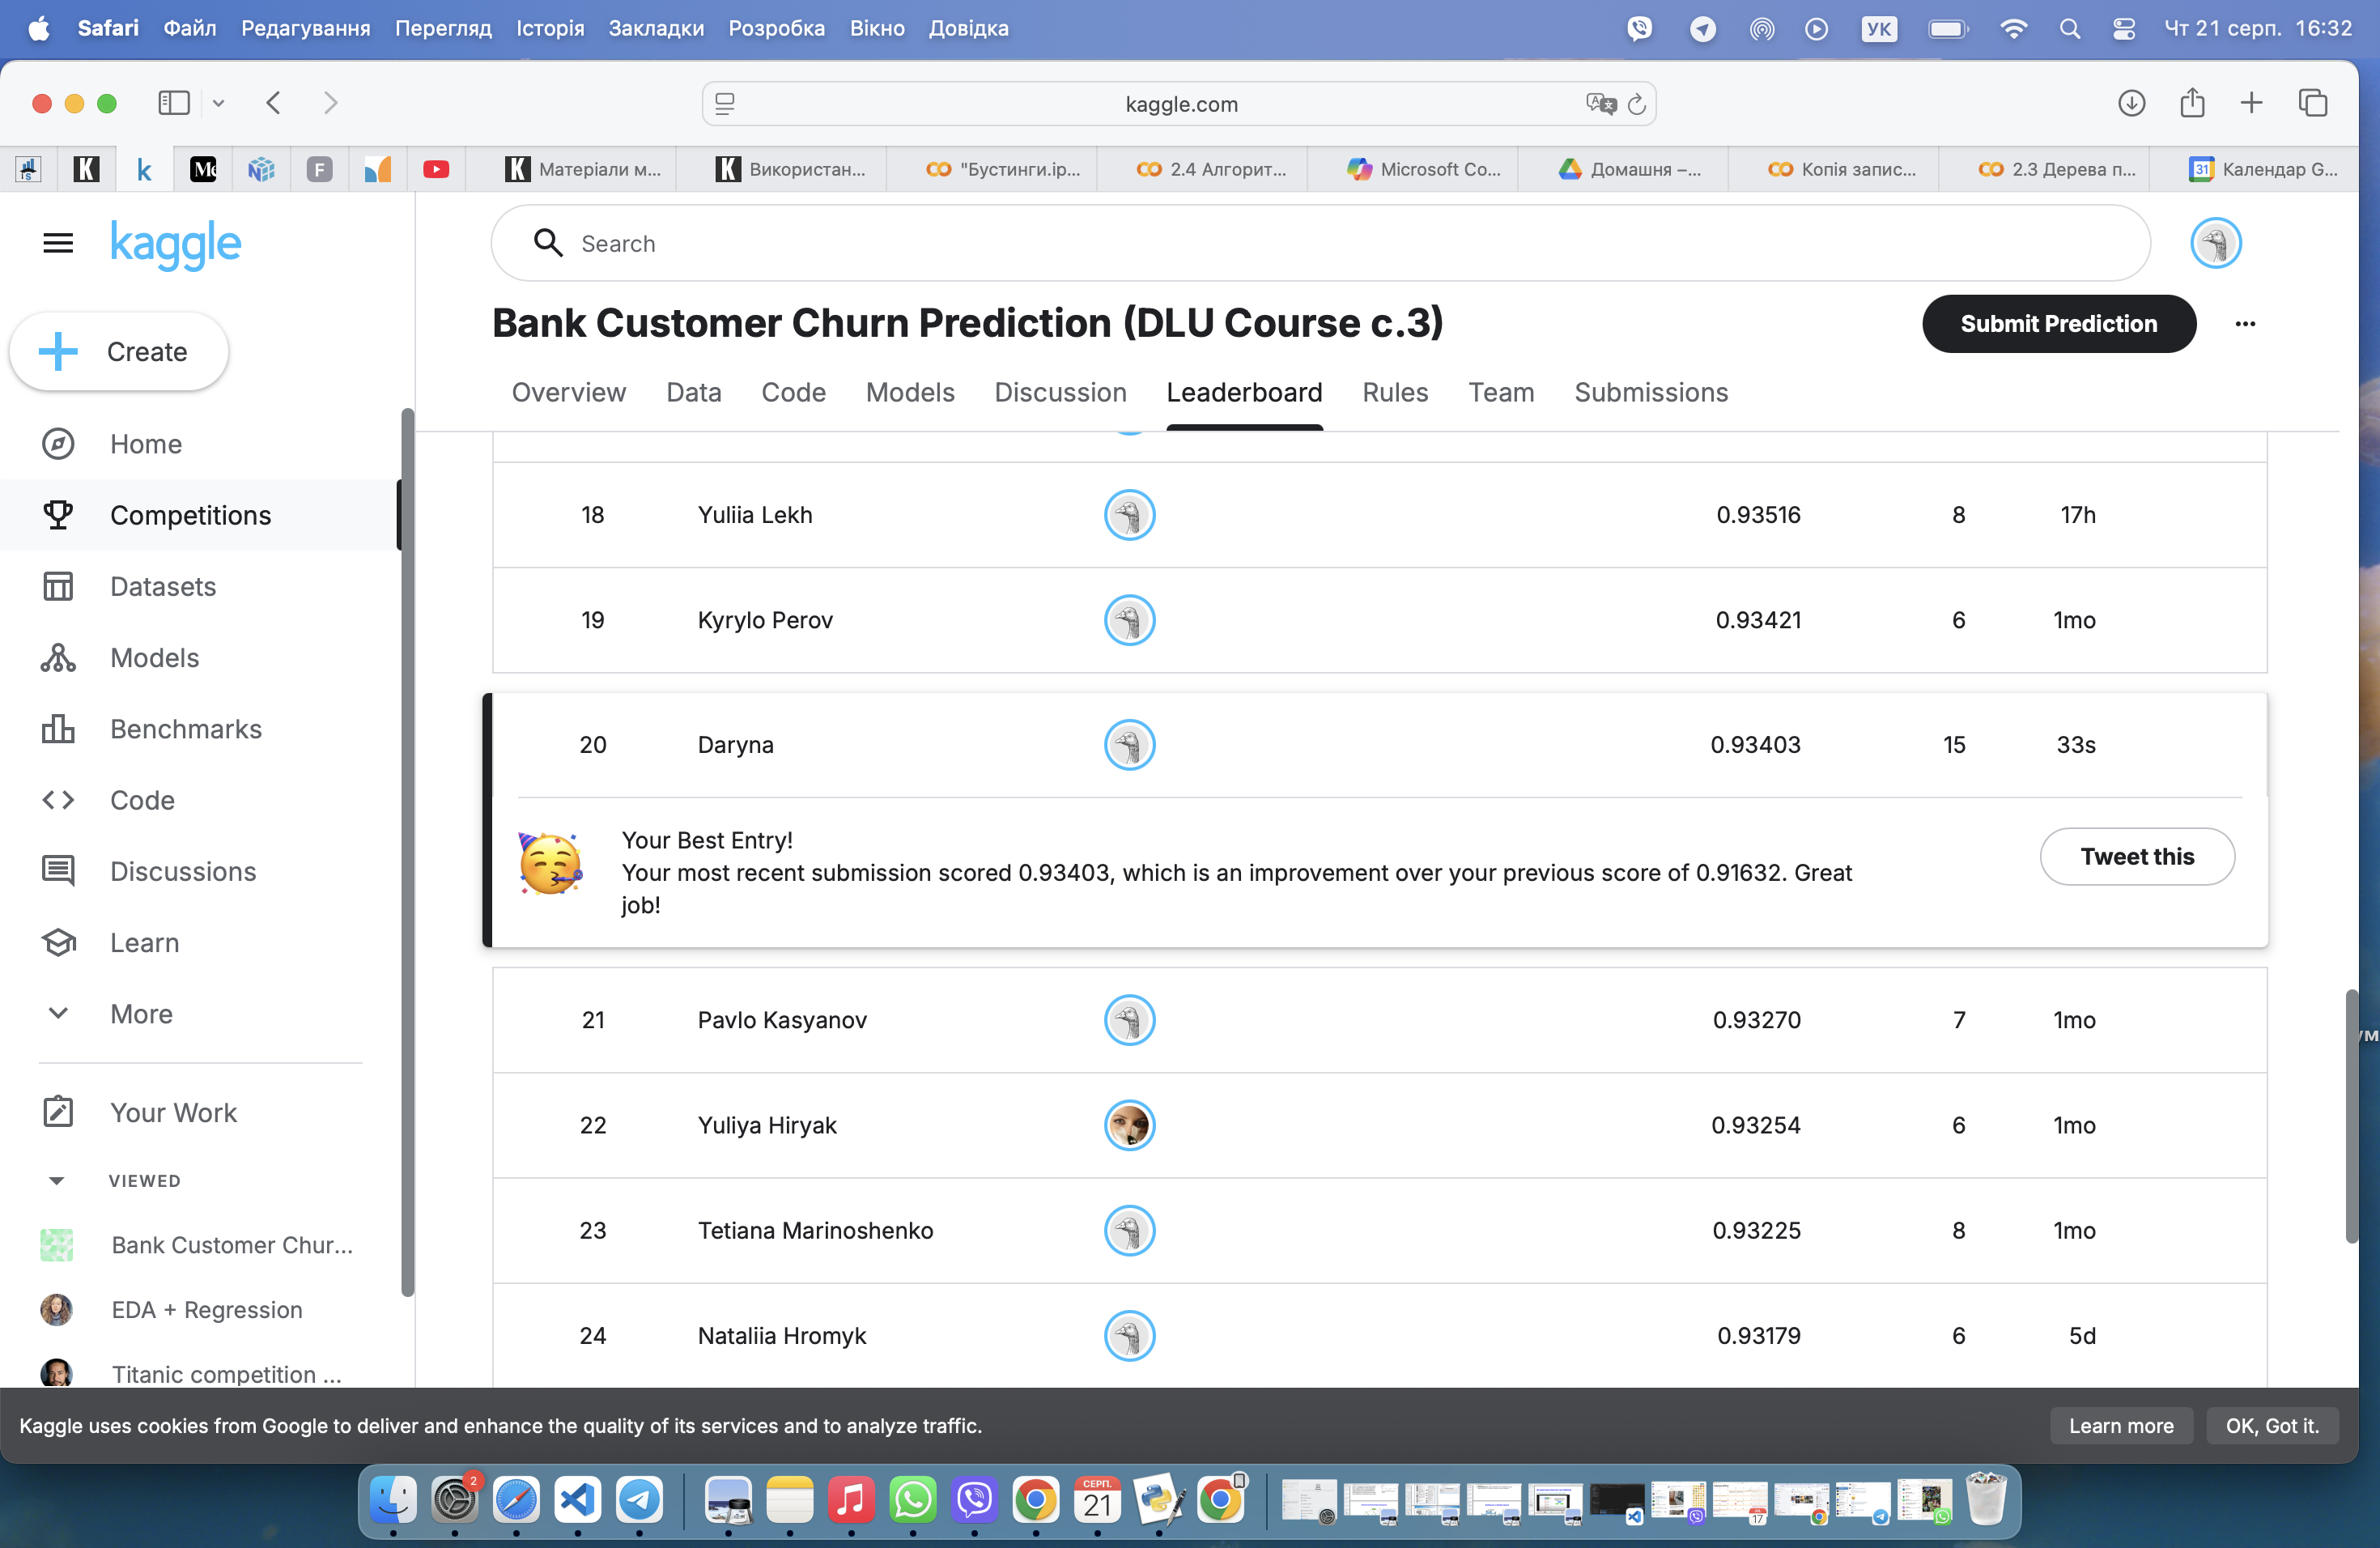